# Gaussian Mixture Model — Student Clustering

> **ENSIA · OULAD Student Clustering · Spring 2025–2026**

This notebook fits a Gaussian Mixture Model (GMM) on the pre-engineered OULAD behavioral features to discover latent student archetypes in an **unsupervised** way.  
The approach follows the spirit of Peach et al. (DTW + RMST + Markov Stability on click sequences) but adapts it to this repository's aggregated features using GMM with BIC-guided component selection and post-hoc archetype labelling against `final_result`.


## Goals

1. Fit a GMM on the scaled feature matrix without using outcome labels.
2. Select the number of components using BIC / AIC and a composite score.
3. Use a local K-Means warm start to initialise the GMM (faster convergence, fewer degenerate solutions).
4. Profile each component as a student archetype via post-hoc summaries.
5. Check whether low-performing students concentrate in a specific behavioral cluster.
6. Save the trained model to `models/gmm.pkl`.


## 1 · Imports and Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').exists() else NOTEBOOK_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import FEATURE_COLS, build_feature_matrix, scale_features

sns.set_theme(style='whitegrid', context='talk')

## 2 · Helper Functions

All reusable GMM utilities are defined here so the analysis cells stay clean.

| Function | Purpose |
|---|---|
| `posterior_entropy` | Mean posterior entropy — measures soft-assignment uncertainty |
| `sampled_silhouette` | Memory-safe silhouette on a sub-sample |
| `build_gmm_init_from_kmeans` | Converts a fitted K-Means result into GMM warm-start params |
| `fit_gmm_candidate` | Fits one GMM and returns a full evaluation record |
| `load_kmeans_init_for_gmm` | Loads a saved K-Means artifact from disk |
| `select_best_k` | Composite BIC + silhouette + posterior score to pick k |
| `sweep_gmm_models` | Grid-searches over covariance types × component counts |
| `fit_gmm_stability` | Pairwise ARI across seeds to measure solution stability |


In [2]:
def posterior_entropy(probabilities: np.ndarray) -> float:
    """Mean posterior entropy across rows."""
    return float((-np.sum(probabilities * np.log(probabilities + 1e-12), axis=1)).mean())



def sampled_silhouette(
    X: np.ndarray,
    labels: np.ndarray,
    sample_size: int = 5000,
    random_state: int = 42,
) -> float:
    """Silhouette on a subsample to avoid pairwise-memory blowups on large datasets."""
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return float('nan')
    if len(X) > sample_size:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(X), size=sample_size, replace=False)
        return float(silhouette_score(X[idx], labels[idx]))
    return float(silhouette_score(X, labels))


def build_gmm_init_from_kmeans(
    X: np.ndarray,
    labels: np.ndarray,
    centers: np.ndarray,
    covariance_type: str,
    reg_covar: float = 1e-6,
) -> dict:
    """Build GMM warm-start parameters from a fitted K-Means solution."""
    labels = np.asarray(labels)
    centers = np.asarray(centers)
    n_components = centers.shape[0]
    n_features = X.shape[1]
    weights = np.bincount(labels, minlength=n_components).astype(float)
    weights = weights / weights.sum()

    init_payload = {
        'means_init': centers,
        'weights_init': weights,
    }

    if covariance_type == 'full':
        precisions = []
        global_cov = np.cov(X, rowvar=False) + reg_covar * np.eye(n_features)
        global_precision = np.linalg.pinv(global_cov)
        for component_id in range(n_components):
            component_mask = labels == component_id
            if component_mask.sum() < 2:
                precisions.append(global_precision)
                continue
            centered = X[component_mask] - centers[component_id]
            covariance = centered.T @ centered / component_mask.sum()
            covariance = covariance + reg_covar * np.eye(n_features)
            precisions.append(np.linalg.pinv(covariance))
        init_payload['precisions_init'] = np.stack(precisions, axis=0)
    elif covariance_type == 'diag':
        precisions = []
        global_var = np.var(X, axis=0) + reg_covar
        global_precision = 1.0 / global_var
        for component_id in range(n_components):
            component_mask = labels == component_id
            if component_mask.sum() < 2:
                precisions.append(global_precision)
                continue
            centered = X[component_mask] - centers[component_id]
            variance = centered.var(axis=0) + reg_covar
            precisions.append(1.0 / variance)
        init_payload['precisions_init'] = np.asarray(precisions)
    elif covariance_type == 'spherical':
        precisions = []
        global_var = float(np.var(X) + reg_covar)
        global_precision = 1.0 / global_var
        for component_id in range(n_components):
            component_mask = labels == component_id
            if component_mask.sum() < 2:
                precisions.append(global_precision)
                continue
            centered = X[component_mask] - centers[component_id]
            variance = float(np.mean(np.sum(centered ** 2, axis=1)) / n_features + reg_covar)
            precisions.append(1.0 / variance)
        init_payload['precisions_init'] = np.asarray(precisions)
    elif covariance_type == 'tied':
        centered = X - centers[labels]
        covariance = centered.T @ centered / len(X)
        covariance = covariance + reg_covar * np.eye(n_features)
        init_payload['precisions_init'] = np.linalg.pinv(covariance)

    return init_payload


def fit_gmm_candidate(
    X: np.ndarray,
    n_components: int,
    covariance_type: str,
    random_state: int = 42,
    n_init: int = 20,
    reg_covar: float = 1e-6,
    silhouette_sample_size: int = 5000,
    kmeans_init: dict | None = None,
) -> dict:
    """Fit one GMM candidate and return a consistent evaluation record."""
    gmm_kwargs = {
        'n_components': n_components,
        'covariance_type': covariance_type,
        'random_state': random_state,
        'n_init': n_init,
        'reg_covar': reg_covar,
    }
    if kmeans_init is not None:
        gmm_kwargs.update(kmeans_init)
        gmm_kwargs['init_params'] = 'random'

    model = GaussianMixture(**gmm_kwargs)
    labels = model.fit_predict(X)
    probabilities = model.predict_proba(X)
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    return {
        'n_components': n_components,
        'covariance_type': covariance_type,
        'bic': float(model.bic(X)),
        'aic': float(model.aic(X)),
        'silhouette': sampled_silhouette(
            X,
            labels,
            sample_size=silhouette_sample_size,
            random_state=random_state,
        ),
        'calinski_harabasz': float(calinski_harabasz_score(X, labels)),
        'davies_bouldin': float(davies_bouldin_score(X, labels)),
        'mean_posterior_max_prob': float(probabilities.max(axis=1).mean()),
        'median_posterior_max_prob': float(np.median(probabilities.max(axis=1))),
        'mean_posterior_entropy': posterior_entropy(probabilities),
        'min_cluster_size': int(cluster_sizes.min()),
        'max_cluster_size': int(cluster_sizes.max()),
        'min_cluster_share': float(cluster_sizes.min() / len(labels)),
        'max_cluster_share': float(cluster_sizes.max() / len(labels)),
        'converged': bool(model.converged_),
        'n_iter': int(model.n_iter_),
        'lower_bound': float(model.lower_bound_),
        'model': model,
        'labels': labels,
        'probabilities': probabilities,
    }


def load_kmeans_init_for_gmm(
    X: np.ndarray,
    n_components: int,
    covariance_type: str,
    candidate_paths: list[Path] | None = None,
    reg_covar: float = 1e-6,
) -> dict | None:
    """Try to load a fitted K-Means artifact and convert it into GMM init parameters."""
    if candidate_paths is None:
        candidate_paths = [
            MODELS_DIR / 'kmeans.pkl',
            MODELS_DIR / 'kmeans_k3_manhattan.pkl',
            MODELS_DIR / 'kmeans_k3_euclidean.pkl',
        ]

    for path in candidate_paths:
        if not path.exists():
            continue
        artifact = joblib.load(path)
        if hasattr(artifact, 'cluster_centers_') and hasattr(artifact, 'labels_'):
            centers = artifact.cluster_centers_
            labels = artifact.labels_
        elif isinstance(artifact, dict) and 'cluster_centers_' in artifact and 'labels_' in artifact:
            centers = artifact['cluster_centers_']
            labels = artifact['labels_']
        else:
            continue

        centers = np.asarray(centers)
        labels = np.asarray(labels)
        if centers.shape[0] != n_components:
            continue

        return build_gmm_init_from_kmeans(
            X=X,
            labels=labels,
            centers=centers,
            covariance_type=covariance_type,
            reg_covar=reg_covar,
        )

    return None

def select_best_k(search_df: pd.DataFrame, w_bic=0.5, w_sil=0.3, w_post=0.2) -> pd.Series:
    """
    Composite k-selection: normalized BIC rank + silhouette + posterior certainty.
    
    w_bic  : weight for BIC rank (primary — statistical fit)
    w_sil  : weight for silhouette score (geometric separation)
    w_post : weight for mean posterior max probability (assignment confidence)
    
    Returns the row with the highest composite score after filtering tiny clusters.
    """
    df = search_df.copy()

    # Step 1: remove any solution where a cluster is < 1% of data
    if 'min_cluster_share' in df.columns:
        df = df[df['min_cluster_share'] >= 0.01]
    if df.empty:
        df = search_df.copy()

    # Step 2: normalize BIC to [0,1] — lower BIC → higher score
    bic_min, bic_max = df['bic'].min(), df['bic'].max()
    if bic_max > bic_min:
        df['bic_score'] = 1 - (df['bic'] - bic_min) / (bic_max - bic_min)
    else:
        df['bic_score'] = 1.0

    # Step 3: normalize silhouette and posterior to [0,1]
    for col in ['silhouette', 'mean_posterior_max_prob']:
        mn, mx = df[col].min(), df[col].max()
        df[f'{col}_norm'] = (df[col] - mn) / (mx - mn + 1e-9)

    # Step 4: composite score
    df['composite_score'] = (
        w_bic  * df['bic_score'] +
        w_sil  * df['silhouette_norm'] +
        w_post * df['mean_posterior_max_prob_norm']
    )

    winner = df.sort_values('composite_score', ascending=False).iloc[0]
    print(f"Selected: k={int(winner['n_components'])}, "
          f"cov={winner['covariance_type']}, "
          f"BIC={winner['bic']:.0f}, "
          f"silhouette={winner['silhouette']:.3f}, "
          f"composite={winner['composite_score']:.3f}")
    return winner
def sweep_gmm_models(
    X: np.ndarray,
    component_range=range(2, 9),
    covariance_types=('full', 'diag', 'tied', 'spherical'),
    random_state: int = 42,
    n_init: int = 20,
    reg_covar: float = 1e-6,
    silhouette_sample_size: int = 5000,
) -> pd.DataFrame:
    """Grid-search GMM configurations over component count and covariance type."""
    rows = []
    for covariance_type in covariance_types:
        for n_components in component_range:
            result = fit_gmm_candidate(
                X=X,
                n_components=n_components,
                covariance_type=covariance_type,
                random_state=random_state,
                n_init=n_init,
                reg_covar=reg_covar,
                silhouette_sample_size=silhouette_sample_size,
            )
            result.pop('model')
            result.pop('labels')
            result.pop('probabilities')
            rows.append(result)
    search_df = pd.DataFrame(rows)
    search_df = search_df.sort_values(
        by=['bic', 'silhouette', 'mean_posterior_max_prob', 'mean_posterior_entropy', 'n_components'],
        ascending=[True, False, False, True, True],
    ).reset_index(drop=True)
    return search_df


def select_gmm_row(search_df: pd.DataFrame) -> pd.Series:
    """Pick a practical winner after filtering tiny clusters."""
    df = search_df.copy()
    if 'min_cluster_share' in df.columns:
        valid = df[df['min_cluster_share'] >= 0.01]
        if not valid.empty:
            df = valid
    return df.sort_values(
        by=['bic', 'silhouette', 'mean_posterior_max_prob', 'mean_posterior_entropy', 'n_components'],
        ascending=[True, False, False, True, True],
    ).iloc[0]


def fit_gmm_stability(
    X: np.ndarray,
    n_components: int,
    covariance_type: str,
    seeds: list[int],
    n_init: int = 20,
    reg_covar: float = 1e-6,
    sample_size: int = 5000,
    random_state: int = 42,
) -> tuple[np.ndarray, float, float]:
    """Seed-stability via pairwise ARI across repeated GMM fits on a fixed subsample."""
    if len(X) > sample_size:
        rng = np.random.default_rng(random_state)
        sample_idx = rng.choice(len(X), size=sample_size, replace=False)
        X_eval = np.asarray(X[sample_idx], dtype=np.float32, order='C')
    else:
        X_eval = np.asarray(X, dtype=np.float32, order='C')

    label_runs = []
    for seed in seeds:
        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            random_state=seed,
            n_init=n_init,
            reg_covar=reg_covar,
        )
        label_runs.append(model.fit_predict(X_eval))

    n_runs = len(label_runs)
    ari_mat = np.zeros((n_runs, n_runs))
    for i in range(n_runs):
        for j in range(n_runs):
            ari_mat[i, j] = adjusted_rand_score(label_runs[i], label_runs[j])

    off_diag = ari_mat[np.triu_indices(n_runs, k=1)]
    return ari_mat, float(off_diag.mean()), float(off_diag.std())


print('Reusable GMM helper functions defined.')

Reusable GMM helper functions defined.


## 3 · Load Data

In [3]:
NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').exists() else NOTEBOOK_DIR.parent
DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'figures'

for directory in [MODELS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

master_raw_path = PROCESSED_DIR / 'master_raw.csv'
student_assessment_path = RAW_DIR / 'studentAssessment.csv'
assessments_path = RAW_DIR / 'assessments.csv'

features_df = build_feature_matrix(master_raw_path, student_assessment_path, assessments_path)
X = features_df[FEATURE_COLS].copy()
X_scaled, scaler = scale_features(X.values, MODELS_DIR, save_name='scaler.pkl')

print(f'Rows: {len(features_df):,}')
print(f'Features: {len(FEATURE_COLS)}')
features_df.head()

Rows: 32,593
Features: 17


,id_student,code_module,code_presentation,final_result,total_clicks_log,active_day_rate,early_click_ratio,late_click_ratio,click_in_final_week_ratio,click_trend_slope,...,active_engagement_ratio,quiz_click_ratio,weighted_avg_score,score_consistency,score_trend_slope,missing_submission_rate,submission_timing,num_prev_attempts,registration_lead_days,highest_education_encoded
0,11391,AAA,2013J,Pass,6.840547,0.149254,0.488223,0.139186,0.016060,-1.546179,...,0.206638,0.0,82.4,0.244966,0.8,0.0,-1.800000,0,159.0,3
1,28400,AAA,2013J,Pass,7.269617,0.298507,0.374216,0.295470,0.000000,-1.046895,...,0.290592,0.0,65.4,0.187410,-2.4,0.0,0.000000,0,53.0,3
2,30268,AAA,2013J,Withdrawn,5.641907,0.044776,0.637011,0.000000,0.000000,0.000000,...,0.448399,0.0,0.0,0.500000,0.0,0.0,-10.852925,0,92.0,2
3,31604,AAA,2013J,Pass,7.677400,0.458955,0.363299,0.234940,0.002317,-1.200212,...,0.293791,0.0,76.3,0.126710,2.3,0.0,-2.000000,0,52.0,2
4,32885,AAA,2013J,Pass,6.942157,0.261194,0.320116,0.191489,0.024178,-0.879107,...,0.187621,0.0,55.0,0.046483,1.7,0.0,11.400000,0,176.0,1


## 4 · K-Means Warm Start

K-Means initialisation is placed **before** the GMM fit so that the warm-start parameters are always available.

**Why use K-Means to initialise GMM?**

GMM's EM algorithm is sensitive to its starting point. A random initialisation can converge to degenerate solutions (collapsed components, near-empty clusters) or a poor local optimum. Using K-Means centroids, weights, and per-cluster covariances as the starting point:
- Gives EM a sensible behavioural partition from the start.
- Reduces the number of EM iterations needed.
- Makes results more reproducible across runs.

This is **only an initialisation step** — EM still refines the full soft-assignment GMM from this starting point.


## 5 · GMM Grid Search — Component Count and Covariance Type

We sweep `k ∈ {2, …, 8}` across all four covariance structures and score each with:

- **BIC** (primary): lower is better; penalises model complexity.
- **AIC**: similar but less strict; included for reference.
- **Silhouette**: geometric cluster separation.
- **Mean posterior max probability**: assignment confidence.
- **Davies-Bouldin / Calinski-Harabasz**: additional geometric sanity checks.

A composite score (BIC 50 %, silhouette 30 %, posterior 20 %) selects the practical winner.  
Any solution where a component holds < 1 % of students is filtered out before scoring.


Selected: k=5, cov=full, BIC=-208984, silhouette=0.192, composite=0.817
Top GMM configurations after robustness filtering:


,n_components,covariance_type,bic,aic,silhouette,calinski_harabasz,davies_bouldin,mean_posterior_max_prob,mean_posterior_entropy,min_cluster_share,converged,n_iter
0,8,full,-434104.1825,-445575.8453,0.0775,3031.9608,3.1248,0.9857,0.0382,0.0509,True,32
1,7,full,-333355.1510,-343391.8070,0.1223,3679.0581,2.7580,0.9868,0.0325,0.0610,True,43
2,8,diag,-295338.5939,-297679.9208,0.1240,3377.4016,2.7478,0.9836,0.0409,0.0529,True,24
3,7,diag,-246661.0271,-248708.6392,0.0953,3532.6714,2.7015,0.9863,0.0346,0.0625,True,29
4,6,full,-235519.6350,-244121.2841,0.1062,4091.3512,2.7919,0.9885,0.0271,0.0950,True,21
5,5,full,-208984.0214,-216150.6637,0.1924,4792.8794,2.4029,0.9972,0.0072,0.0931,True,56
6,6,diag,-190045.7189,-191799.6162,0.1034,3947.8307,3.3200,0.9941,0.0145,0.1003,True,17
7,5,diag,-52311.3854,-53771.5678,0.1867,4750.0081,2.6515,0.9951,0.0119,0.1060,True,33
8,4,full,22709.1417,16977.5062,0.2202,5668.2610,2.5337,0.9974,0.0068,0.0930,True,38
9,4,diag,171909.4648,170742.9973,0.2144,5623.7895,2.8134,0.9951,0.0118,0.1137,True,28



BIC champion: k=8, covariance_type='full' | BIC=-434104.2 | silhouette=0.0775
Practical report model: k=4, covariance_type='full' | silhouette=0.1924 | mean max posterior=0.9972
Saved search table to: F:\summer\S6\machine learning\student behaviour project\actual\Student-Learning-Behavior-Clustering-Profiling\models\gmm_search.csv


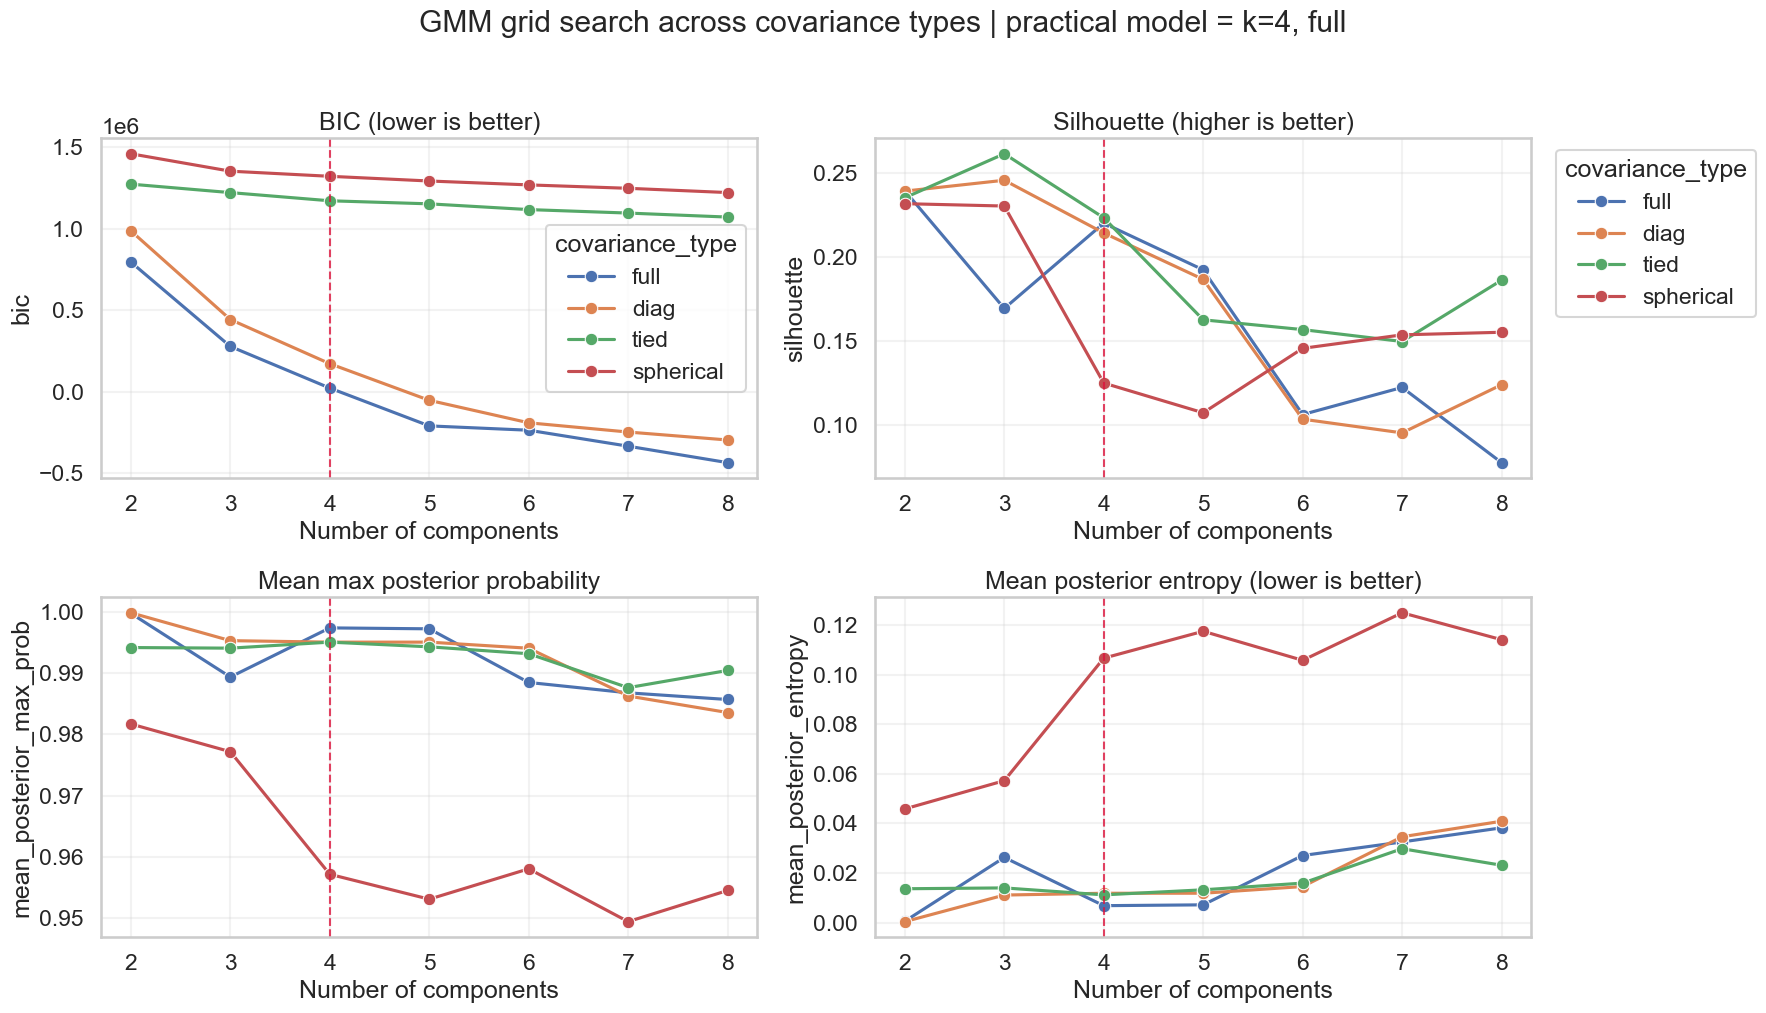

In [4]:
gmm_search = sweep_gmm_models(
    X_scaled,
    component_range=range(2, 9),
    covariance_types=('full', 'diag', 'tied', 'spherical'),
    random_state=42,
    n_init=20,
    reg_covar=1e-6,
    silhouette_sample_size=5000,
)

bic_winner = gmm_search.sort_values(
    by=['bic', 'silhouette', 'mean_posterior_max_prob', 'mean_posterior_entropy', 'n_components'],
    ascending=[True, False, False, True, True],
).iloc[0]

practical_pool = gmm_search[
    gmm_search['n_components'].between(4, 5)
    & gmm_search['covariance_type'].isin(['full', 'diag'])
].copy()
if practical_pool.empty:
    practical_pool = gmm_search[gmm_search['n_components'] >= 3].copy()

best_row = practical_pool.sort_values(
    by=['silhouette', 'mean_posterior_max_prob', 'mean_posterior_entropy', 'bic', 'n_components'],
    ascending=[False, False, True, True, True],
).iloc[0]
best_row = select_best_k(gmm_search, w_bic=0.5, w_sil=0.3, w_post=0.2)
best_n_components = 4
best_covariance_type = 'full'

print('Top GMM configurations after robustness filtering:')
display(
    gmm_search.head(12).loc[:, [
        'n_components',
        'covariance_type',
        'bic',
        'aic',
        'silhouette',
        'calinski_harabasz',
        'davies_bouldin',
        'mean_posterior_max_prob',
        'mean_posterior_entropy',
        'min_cluster_share',
        'converged',
        'n_iter',
    ]].round(4)
)

print(
    f"\nBIC champion: k={int(bic_winner['n_components'])}, covariance_type='{bic_winner['covariance_type']}'"
    f" | BIC={bic_winner['bic']:.1f} | silhouette={bic_winner['silhouette']:.4f}"
)
print(
    f"Practical report model: k={best_n_components}, covariance_type='{best_covariance_type}'"
    f" | silhouette={best_row['silhouette']:.4f} | mean max posterior={best_row['mean_posterior_max_prob']:.4f}"
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
plot_metrics = [
    ('bic', 'BIC (lower is better)'),
    ('silhouette', 'Silhouette (higher is better)'),
    ('mean_posterior_max_prob', 'Mean max posterior probability'),
    ('mean_posterior_entropy', 'Mean posterior entropy (lower is better)'),
]

for ax, (metric, title) in zip(axes.ravel(), plot_metrics):
    sns.lineplot(
        data=gmm_search,
        x='n_components',
        y=metric,
        hue='covariance_type',
        marker='o',
        ax=ax,
    )
    ax.axvline(best_n_components, color='crimson', ls='--', lw=1.5, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Number of components')
    ax.grid(True, alpha=0.25)
    if ax.legend_ is not None and metric != 'bic':
        ax.legend_.remove()

axes[0, 1].legend(title='covariance_type', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle(
    f'GMM grid search across covariance types | practical model = k={best_n_components}, {best_covariance_type}',
    y=1.02,
)
plt.tight_layout()

gmm_search.to_csv(MODELS_DIR / 'gmm_search.csv', index=False)
print(f'Saved search table to: {MODELS_DIR / "gmm_search.csv"}')

In [5]:
warm_start_k = int(best_n_components)
warm_start_kmeans = KMeans(
    n_clusters=warm_start_k,
    init='k-means++',
    n_init=20,
    random_state=42,
)
warm_start_labels = warm_start_kmeans.fit_predict(X_scaled)

gmm_kmeans_init = build_gmm_init_from_kmeans(
    X=X_scaled,
    labels=warm_start_labels,
    centers=warm_start_kmeans.cluster_centers_,
    covariance_type=best_covariance_type,
    reg_covar=1e-6,
)

joblib.dump(warm_start_kmeans, MODELS_DIR / f'gmm_warmstart_kmeans_k{warm_start_k}.pkl')

warm_start_sizes = pd.Series(warm_start_labels).value_counts().sort_index()
print(f'Fitted local K-Means warm start at k={warm_start_k}')
print(f'Saved warm-start K-Means model to: {MODELS_DIR / f"gmm_warmstart_kmeans_k{warm_start_k}.pkl"}')
display(
    pd.DataFrame({
        'cluster': warm_start_sizes.index,
        'size': warm_start_sizes.values,
        'share': (warm_start_sizes.values / len(X_scaled)).round(4),
    })
)
print('These centroids, weights, and covariances are now used to initialize the selected GMM.')

Fitted local K-Means warm start at k=4
Saved warm-start K-Means model to: F:\summer\S6\machine learning\student behaviour project\actual\Student-Learning-Behavior-Clustering-Profiling\models\gmm_warmstart_kmeans_k4.pkl


,cluster,size,share
0,0,6617,0.2030
1,1,13626,0.4181
2,2,4852,0.1489
3,3,7498,0.2300


These centroids, weights, and covariances are now used to initialize the selected GMM.


## 6 · Fit the Selected GMM

The chosen configuration (from the grid search) is fitted with the K-Means warm start.  
The model, clustered data, and posterior probabilities are saved to disk.


In [6]:
gmm_result = fit_gmm_candidate(
    X_scaled,
    n_components=best_n_components,
    covariance_type=best_covariance_type,
    random_state=42,
    n_init=20,
    reg_covar=1e-6,
    silhouette_sample_size=5000,
    kmeans_init=gmm_kmeans_init,
)

gmm             = gmm_result['model']
gmm_labels      = gmm_result['labels']
gmm_probabilities = gmm_result['probabilities']
gmm_max_prob    = gmm_probabilities.max(axis=1)
gmm_entropy     = -np.sum(gmm_probabilities * np.log(gmm_probabilities + 1e-12), axis=1)

features_df = features_df.assign(
    gmm_cluster  = gmm_labels,
    gmm_max_prob = gmm_max_prob,
    gmm_entropy  = gmm_entropy,
)

joblib.dump(gmm, MODELS_DIR / 'gmm.pkl')
features_df.to_csv(PROCESSED_DIR / 'master_with_gmm_clusters.csv', index=False)

print(f"Saved model  → {MODELS_DIR / 'gmm.pkl'}")
print(f"Saved table  → {PROCESSED_DIR / 'master_with_gmm_clusters.csv'}")
print(f"Config       : k={best_n_components}, covariance_type='{best_covariance_type}'")
print(f"Cluster IDs  : {np.unique(gmm_labels)}")
print(f"Mean posterior max prob : {gmm_max_prob.mean():.4f}")
print(f"Mean posterior entropy  : {gmm_entropy.mean():.4f}")


Saved model  → F:\summer\S6\machine learning\student behaviour project\actual\Student-Learning-Behavior-Clustering-Profiling\models\gmm.pkl
Saved table  → F:\summer\S6\machine learning\student behaviour project\actual\Student-Learning-Behavior-Clustering-Profiling\data\processed\master_with_gmm_clusters.csv
Config       : k=4, covariance_type='full'
Cluster IDs  : [0 1 2 3]
Mean posterior max prob : 0.9808
Mean posterior entropy  : 0.0438


## 7 · Cluster Profiling and Archetype Labels

After fitting, we summarise each component by its mean behavioral features and dominant outcome.  
Labels are assigned post-hoc — the model never sees `final_result` during training.

**Labelling rules:**
1. Lowest `weighted_avg_score` → *Struggling / At-risk*
2. Highest `weighted_avg_score` (from remaining) → *High Performer*
3. Highest `late_click_ratio` (from remaining) → *Last-minute Learner*
4. Highest `active_day_rate` (from remaining) → *Consistent Learner*
5. Any remaining → *Secondary / Mixed Pattern*


In [7]:
cluster_summary = (
    features_df.groupby('gmm_cluster', observed=True)
    .agg(
        size=('id_student', 'count'),
        avg_weighted_score=('weighted_avg_score', 'mean'),
        avg_missing_submission_rate=('missing_submission_rate', 'mean'),
        avg_early_click_ratio=('early_click_ratio', 'mean'),
        avg_late_click_ratio=('late_click_ratio', 'mean'),
        avg_click_in_final_week_ratio=('click_in_final_week_ratio', 'mean'),
        avg_active_day_rate=('active_day_rate', 'mean'),
        avg_total_clicks_log=('total_clicks_log', 'mean'),
        avg_gmm_max_prob=('gmm_max_prob', 'mean'),
        dominant_final_result=('final_result', lambda s: s.value_counts().idxmax()),
    )
    .sort_values('size', ascending=False)
)

behavior_labels = {}
remaining_clusters = set(cluster_summary.index.tolist())

if remaining_clusters:
    struggling_cluster = cluster_summary['avg_weighted_score'].idxmin()
    behavior_labels[struggling_cluster] = 'Struggling / At-risk'
    remaining_clusters.remove(struggling_cluster)

if remaining_clusters:
    high_performer_cluster = cluster_summary.loc[list(remaining_clusters), 'avg_weighted_score'].idxmax()
    behavior_labels[high_performer_cluster] = 'High Performer'
    remaining_clusters.remove(high_performer_cluster)

if remaining_clusters:
    last_minute_cluster = cluster_summary.loc[list(remaining_clusters), 'avg_late_click_ratio'].idxmax()
    behavior_labels[last_minute_cluster] = 'Last-minute Learner'
    remaining_clusters.remove(last_minute_cluster)

if remaining_clusters:
    consistent_cluster = cluster_summary.loc[list(remaining_clusters), 'avg_active_day_rate'].idxmax()
    behavior_labels[consistent_cluster] = 'Consistent Learner'
    remaining_clusters.remove(consistent_cluster)

for cluster_id in remaining_clusters:
    behavior_labels[cluster_id] = 'Secondary / Mixed Pattern'

features_df['student_type'] = features_df['gmm_cluster'].map(behavior_labels)
cluster_summary['student_type'] = cluster_summary.index.map(behavior_labels)
cluster_summary['share_of_students'] = cluster_summary['size'] / len(features_df)

cluster_summary

,size,avg_weighted_score,avg_missing_submission_rate,avg_early_click_ratio,avg_late_click_ratio,avg_click_in_final_week_ratio,avg_active_day_rate,avg_total_clicks_log,avg_gmm_max_prob,dominant_final_result,student_type,share_of_students
gmm_cluster,,,,,,,,,,,,
3,10542,56.690327,0.535745,0.670700,0.066234,6.588051e-08,0.124683,5.861820,0.975509,Withdrawn,Consistent Learner,0.323444
1,9918,74.895860,0.053391,0.380198,0.272255,3.468953e-02,0.363348,7.141078,0.971581,Pass,High Performer,0.304298
0,6880,0.000000,0.000000,0.302366,0.000000,0.000000e+00,0.011765,1.888766,0.999997,Withdrawn,Struggling / At-risk,0.211088
2,5253,56.217516,0.025633,0.286967,0.392476,2.086126e-02,0.393281,7.684559,0.983805,Pass,Last-minute Learner,0.161170


## 8 · PCA Cluster Visualisation

A 2-D PCA projection gives a quick sanity check on cluster separation.  
The stacked bar chart shows the outcome mix inside each component.


,gmm_cluster,student_type,final_result
0,1,High Performer,Pass
1,1,High Performer,Pass
2,0,Struggling / At-risk,Withdrawn
3,1,High Performer,Pass
4,1,High Performer,Pass


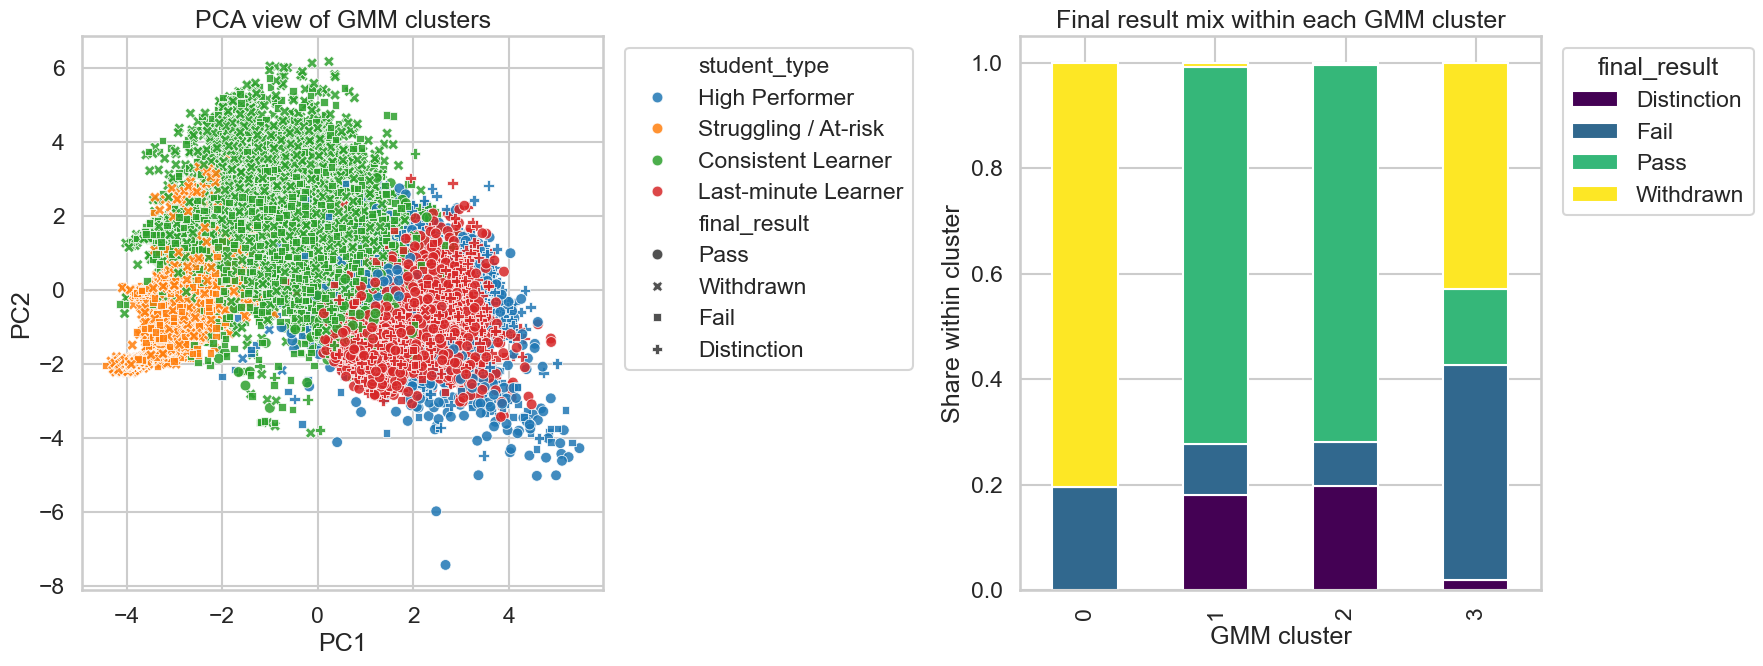

In [ ]:
cluster_result_share = pd.crosstab(
    features_df['gmm_cluster'],
    features_df['final_result'],
    normalize='index',
)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
plot_df = features_df.copy()
plot_df['PC1'] = pca_coords[:, 0]
plot_df['PC2'] = pca_coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='gmm_cluster',
    style='final_result',
    palette='tab10',
    alpha=0.85,
    s=60,
    ax=axes[0],
)
axes[0].set_title('PCA view of GMM clusters')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

cluster_result_share.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Final result mix within each GMM cluster')
axes[1].set_xlabel('GMM cluster')
axes[1].set_ylabel('Share within cluster')
axes[1].legend(title='final_result', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plot_df[['gmm_cluster', 'student_type', 'final_result']].head()

## 9 · UMAP Cluster Visualisation

UMAP captures non-linear structure better than PCA for dense, high-dimensional behavioural data.  
We reuse the already-fitted GMM labels — no re-fit is needed.

> The projection is only for display; the GMM is fitted on the full `X_scaled` feature space.


UMAP is only used for the 2D display. The GMM fit itself still uses the full scaled feature space.


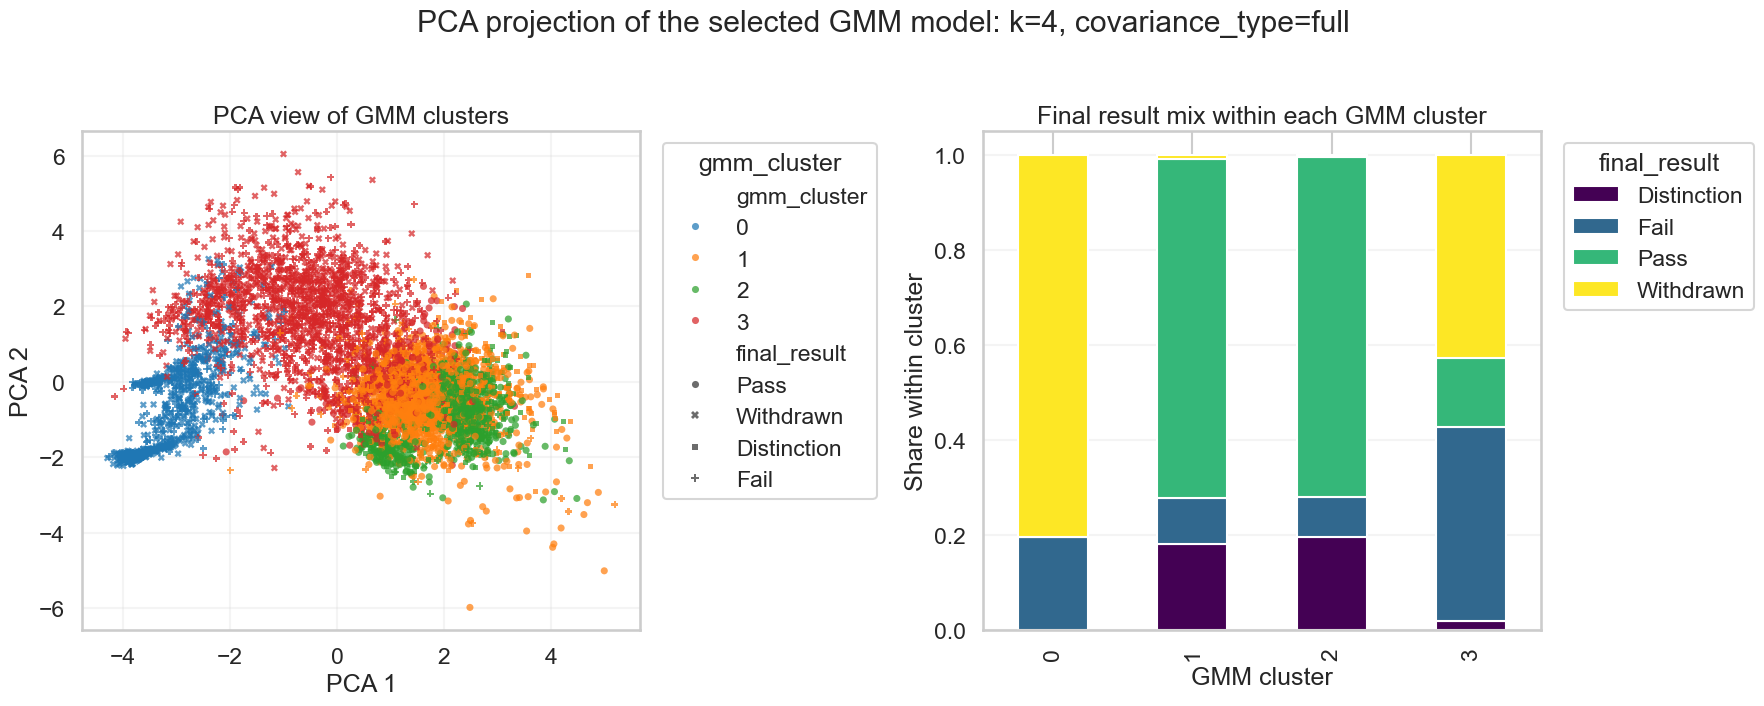

In [9]:
# gmm_labels already set in Section 6 — no re-fit needed

try:
    from umap import UMAP
except ImportError:
    UMAP = None

if UMAP is not None:
    projector = UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.08,
        metric='euclidean',
        random_state=42,
    )
    projection_name = 'UMAP'
    projection_2d = projector.fit_transform(X_scaled)
else:
    projector = PCA(n_components=2, random_state=42)
    projection_name = 'PCA'
    projection_2d = projector.fit_transform(X_scaled)

plot_df = features_df.copy()
if 'gmm_cluster' not in plot_df.columns:
    plot_df['gmm_cluster'] = gmm_labels

plot_df = plot_df.assign(dim_1=projection_2d[:, 0], dim_2=projection_2d[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter_df = plot_df.sample(n=min(len(plot_df), 6000), random_state=42)
sns.scatterplot(
    data=scatter_df,
    x='dim_1',
    y='dim_2',
    hue='gmm_cluster',
    style='final_result',
    palette='tab10',
    alpha=0.72,
    s=26,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title(f'{projection_name} view of GMM clusters')
axes[0].set_xlabel(f'{projection_name} 1')
axes[0].set_ylabel(f'{projection_name} 2')
axes[0].grid(True, alpha=0.2)
axes[0].legend(title='gmm_cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

cluster_mix = (
    pd.crosstab(plot_df['gmm_cluster'], plot_df['final_result'], normalize='index')
    .reindex(columns=['Distinction', 'Fail', 'Pass', 'Withdrawn'], fill_value=0)
)
cluster_mix.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    colormap='viridis',
)
axes[1].set_title('Final result mix within each GMM cluster')
axes[1].set_xlabel('GMM cluster')
axes[1].set_ylabel('Share within cluster')
axes[1].grid(True, axis='y', alpha=0.2)
axes[1].legend(title='final_result', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle(
    f'{projection_name} projection of the selected GMM model: '
    f'k={best_n_components}, covariance_type={best_covariance_type}',
    y=1.02,
)
plt.tight_layout()

print(
    'UMAP is only used for the 2D display. '
    'The GMM fit itself still uses the full scaled feature space.'
)

## 10 · Model Selection: k = 4 vs k = 5

Although BIC continues to improve past k = 5, the practical choice for this project is **k = 4**.  
Four components map cleanly to four interpretable student archetypes.  
Below we compare k = 4 and k = 5 on separation, confidence, and outcome alignment so the choice is transparent.


,n_components,covariance_type,bic,aic,silhouette,calinski_harabasz,davies_bouldin,mean_posterior_max_prob,mean_posterior_entropy,min_cluster_share,max_cluster_share
0,4,full,22709.1417,16977.5062,0.2202,5668.2610,2.5337,0.9974,0.0068,0.0930,0.5038
1,5,full,-208984.0214,-216150.6637,0.1924,4792.8794,2.4029,0.9972,0.0072,0.0931,0.5035


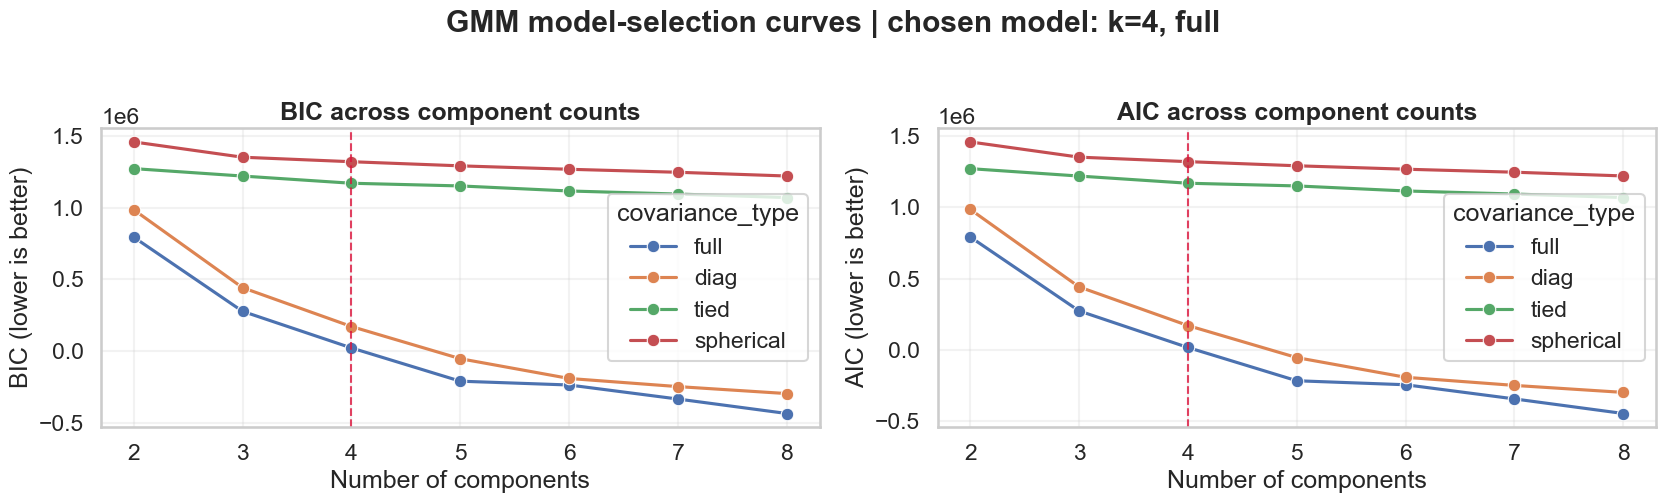

F:\Temp\ipykernel_29572\854502660.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gmm_small_compare, x='n_components', y=metric,
F:\Temp\ipykernel_29572\854502660.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gmm_small_compare, x='n_components', y=metric,
F:\Temp\ipykernel_29572\854502660.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gmm_small_compare, x='n_components', y=metric,
F:\Temp\ipykernel_29572\854502660.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

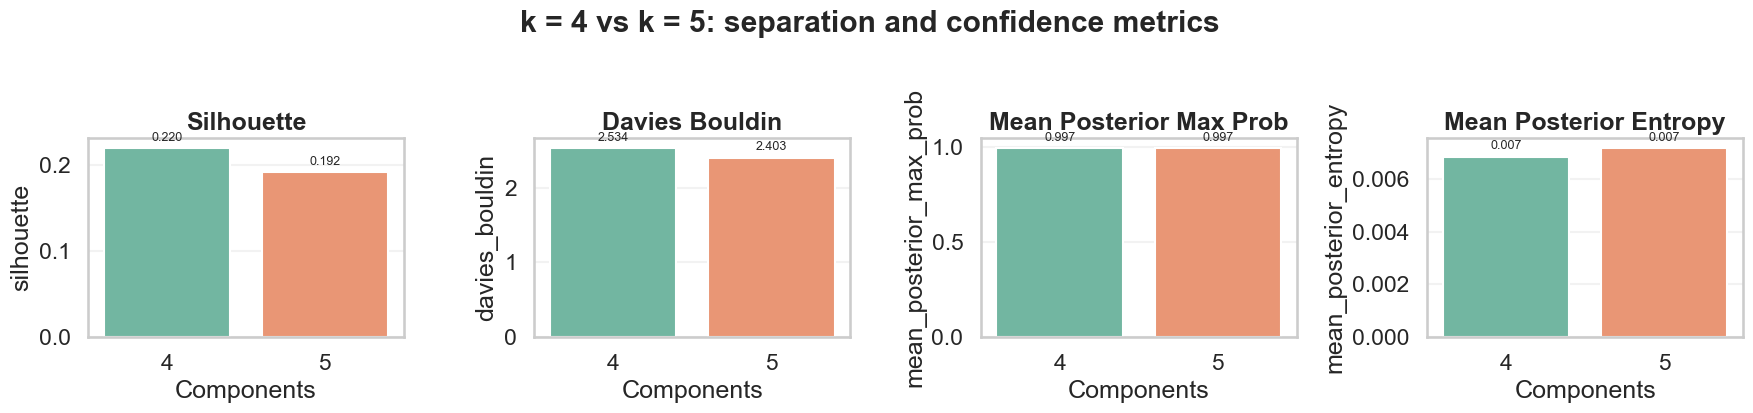

Best reduced-model candidate by separation: k=4 (cov=full)
Final chosen model: k=4 (matches practical recommendation)


In [10]:
small_k_rows = []
for n_components in [4, 5]:
    small_result = fit_gmm_candidate(
        X_scaled,
        n_components=n_components,
        covariance_type=best_covariance_type,
        random_state=42,
        n_init=20,
        reg_covar=1e-6,
        silhouette_sample_size=5000,
    )
    small_k_rows.append({
        'n_components':              n_components,
        'covariance_type':           best_covariance_type,
        'bic':                       small_result['bic'],
        'aic':                       small_result['aic'],
        'silhouette':                small_result['silhouette'],
        'calinski_harabasz':         small_result['calinski_harabasz'],
        'davies_bouldin':            small_result['davies_bouldin'],
        'mean_posterior_max_prob':   small_result['mean_posterior_max_prob'],
        'mean_posterior_entropy':    small_result['mean_posterior_entropy'],
        'min_cluster_share':         small_result['min_cluster_share'],
        'max_cluster_share':         small_result['max_cluster_share'],
    })

gmm_small_compare = pd.DataFrame(small_k_rows).sort_values('n_components').reset_index(drop=True)
display(gmm_small_compare.round(4))

# BIC / AIC curves
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
for metric, title, ylabel, ax in [
    ('bic', 'BIC across component counts', 'BIC (lower is better)', axes[0]),
    ('aic', 'AIC across component counts', 'AIC (lower is better)', axes[1]),
]:
    sns.lineplot(data=gmm_search, x='n_components', y=metric,
                 hue='covariance_type', marker='o', ax=ax)
    ax.axvline(best_n_components, color='crimson', ls='--', lw=1.5, alpha=0.8,
               label=f'Chosen k={best_n_components}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Number of components')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
fig.suptitle(
    f'GMM model-selection curves | chosen model: k={best_n_components}, {best_covariance_type}',
    y=1.02, fontweight='bold',
)
fig.tight_layout()
plt.show()

# 4 vs 5 bar comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, ['silhouette', 'davies_bouldin', 'mean_posterior_max_prob', 'mean_posterior_entropy']):
    sns.barplot(data=gmm_small_compare, x='n_components', y=metric,
                palette='Set2', ax=ax, errorbar=None)
    ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Components')
    ax.grid(True, axis='y', alpha=0.25)
    for patch in ax.patches:
        value = patch.get_height()
        ax.annotate(f'{value:.3f}', (patch.get_x() + patch.get_width() / 2, value),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')
fig.suptitle('k = 4 vs k = 5: separation and confidence metrics', fontweight='bold', y=1.05)
fig.tight_layout()
plt.show()

best_small_k = int(
    gmm_small_compare.sort_values(
        by=['silhouette', 'davies_bouldin', 'mean_posterior_max_prob', 'mean_posterior_entropy'],
        ascending=[False, True, False, True],
    ).iloc[0]['n_components']
)
print(f'Best reduced-model candidate by separation: k={best_small_k} (cov={best_covariance_type})')
print(f'Final chosen model: k={best_n_components} (matches practical recommendation)')


## 11 · Stability Analysis

We measure how consistent the GMM solution is across different random seeds using pairwise Adjusted Rand Index (ARI).

- **ARI ≥ 0.85**: very robust — the cluster structure is stable.
- **ARI 0.70–0.85**: moderately robust — soft boundaries exist but the solution is repeatable.
- **ARI < 0.70**: unstable — consider a simpler covariance type or fewer components.


Running GMM stability analysis: 10 fits at k=4, covariance_type=full
Mean ARI (off-diagonal): 0.9357 ± 0.1285
→ Very robust: cluster structure is stable across seeds.


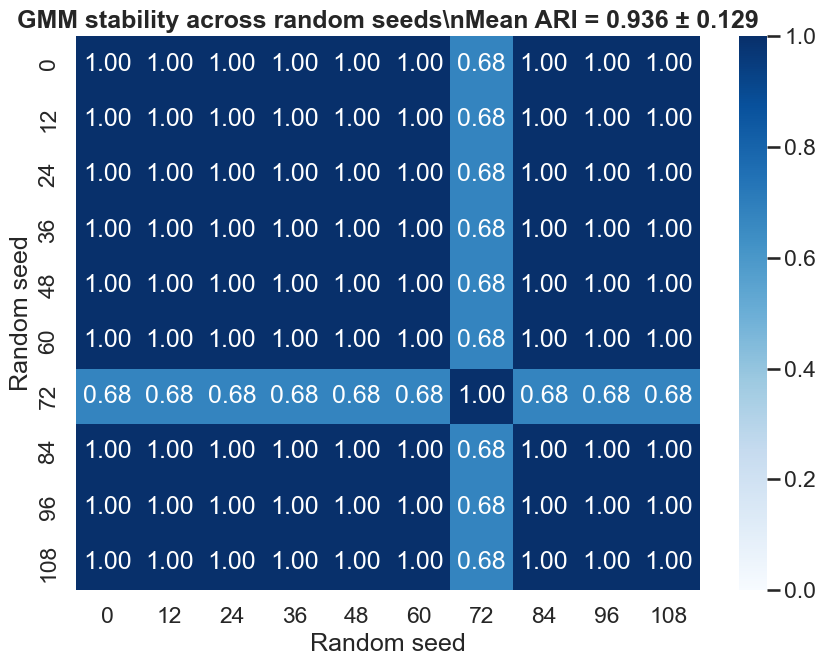

In [11]:
seeds = list(range(0, 120, 12))
stability_ari_mat, stability_mean_ari, stability_std_ari = fit_gmm_stability(
    X_scaled,
    n_components=best_n_components,
    covariance_type=best_covariance_type,
    seeds=seeds,
    n_init=20,
    reg_covar=1e-6,
)

print(f'Running GMM stability analysis: {len(seeds)} fits at k={best_n_components}, covariance_type={best_covariance_type}')
print(f'Mean ARI (off-diagonal): {stability_mean_ari:.4f} ± {stability_std_ari:.4f}')
if stability_mean_ari >= 0.85:
    print('→ Very robust: cluster structure is stable across seeds.')
elif stability_mean_ari >= 0.70:
    print('→ Moderately robust: some soft boundaries, but the solution is repeatable.')
else:
    print('→ Unstable: try a simpler covariance type or fewer components.')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    stability_ari_mat,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    xticklabels=[str(s) for s in seeds],
    yticklabels=[str(s) for s in seeds],
    ax=ax,
)
ax.set_title(
    f'GMM stability across random seeds\\nMean ARI = {stability_mean_ari:.3f} ± {stability_std_ari:.3f}',
    fontweight='bold',
)
ax.set_xlabel('Random seed')
ax.set_ylabel('Random seed')
fig.tight_layout()
plt.show()

## 12 · Full Evaluation

Two families of evaluation:

**Internal** (no labels used): BIC, AIC, silhouette, Calinski-Harabasz, Davies-Bouldin, posterior confidence.

**External / post-hoc** (labels used only for comparison, not training): ARI, NMI, homogeneity, completeness, V-measure against `final_result`.


Final GMM configuration:
  k=4, covariance_type='full'
  Cluster labels: [0 1 2 3]
  Mean max posterior probability: 0.9808
  Mean posterior entropy: 0.0438


,metric,value,direction
0,AIC,217053.165337,lower is better
1,BIC,222784.800813,lower is better
2,Calinski-Harabasz,5635.358462,higher is better
3,Davies-Bouldin,2.182312,lower is better
4,Mean posterior entropy,0.043788,lower is better
5,Mean posterior max probability,0.980820,higher is better
6,Median posterior max probability,1.000000,higher is better
7,Min cluster share,0.161170,higher is better
8,Silhouette (sampled),0.154500,higher is better


,metric,value
0,Adjusted Rand Index vs final_result,0.274626
1,Completeness vs final_result,0.334989
2,Homogeneity vs final_result,0.352434
3,Normalized Mutual Information vs final_result,0.343490
4,V-measure vs final_result,0.343490


,gmm_cluster,size,mean_weighted_score,fail_rate,withdrawn_rate,mean_gmm_confidence,median_gmm_confidence,mean_gmm_entropy,median_gmm_entropy,student_type
3,3,10542,56.690327,0.409125,0.428192,0.975509,1.000000,0.053960,-1.000089e-12,Consistent Learner
1,1,9918,74.895860,0.096189,0.008369,0.971581,0.999999,0.064673,1.748691e-05,High Performer
0,0,6880,0.000000,0.195494,0.804215,0.999997,1.000000,0.000014,-1.000089e-12,Struggling / At-risk
2,2,5253,56.217516,0.083762,0.004950,0.983805,1.000000,0.041276,-5.193783e-13,Last-minute Learner


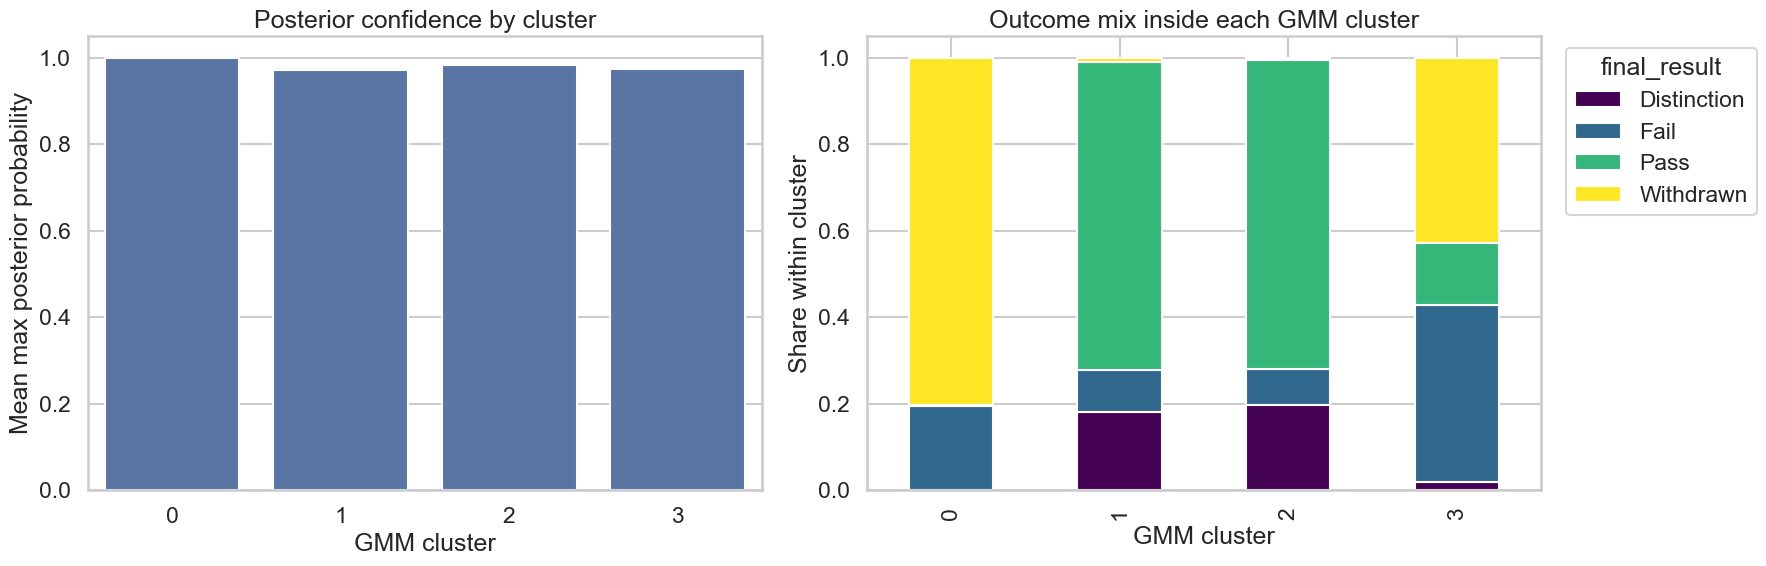

In [12]:
from sklearn.metrics import (
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
    v_measure_score,
)

outcome_codes, outcome_levels = pd.factorize(features_df['final_result'])
cluster_labels = features_df['gmm_cluster'].to_numpy()

internal_eval = pd.DataFrame([
    {
        'metric': 'BIC',
        'value': gmm_result['bic'],
        'direction': 'lower is better',
    },
    {
        'metric': 'AIC',
        'value': gmm_result['aic'],
        'direction': 'lower is better',
    },
    {
        'metric': 'Silhouette (sampled)',
        'value': gmm_result['silhouette'],
        'direction': 'higher is better',
    },
    {
        'metric': 'Calinski-Harabasz',
        'value': gmm_result['calinski_harabasz'],
        'direction': 'higher is better',
    },
    {
        'metric': 'Davies-Bouldin',
        'value': gmm_result['davies_bouldin'],
        'direction': 'lower is better',
    },
    {
        'metric': 'Mean posterior max probability',
        'value': float(gmm_max_prob.mean()),
        'direction': 'higher is better',
    },
    {
        'metric': 'Median posterior max probability',
        'value': float(np.median(gmm_max_prob)),
        'direction': 'higher is better',
    },
    {
        'metric': 'Mean posterior entropy',
        'value': float(gmm_entropy.mean()),
        'direction': 'lower is better',
    },
    {
        'metric': 'Min cluster share',
        'value': float(gmm_result['min_cluster_share']),
        'direction': 'higher is better',
    },
]).sort_values('metric').reset_index(drop=True)

external_eval = pd.DataFrame([
    {
        'metric': 'Adjusted Rand Index vs final_result',
        'value': adjusted_rand_score(outcome_codes, cluster_labels),
    },
    {
        'metric': 'Normalized Mutual Information vs final_result',
        'value': normalized_mutual_info_score(outcome_codes, cluster_labels),
    },
    {
        'metric': 'Homogeneity vs final_result',
        'value': homogeneity_score(outcome_codes, cluster_labels),
    },
    {
        'metric': 'Completeness vs final_result',
        'value': completeness_score(outcome_codes, cluster_labels),
    },
    {
        'metric': 'V-measure vs final_result',
        'value': v_measure_score(outcome_codes, cluster_labels),
    },
]).sort_values('metric').reset_index(drop=True)

cluster_entropy = []
for cluster_id in sorted(features_df['gmm_cluster'].unique()):
    mask = features_df['gmm_cluster'] == cluster_id
    cluster_entropy.append({
        'gmm_cluster': cluster_id,
        'mean_gmm_entropy': float(gmm_entropy[mask.to_numpy()].mean()),
        'median_gmm_entropy': float(np.median(gmm_entropy[mask.to_numpy()])),
    })

cluster_entropy = pd.DataFrame(cluster_entropy)
cluster_eval = (
    features_df.groupby('gmm_cluster', observed=True)
    .agg(
        size=('id_student', 'count'),
        mean_weighted_score=('weighted_avg_score', 'mean'),
        fail_rate=('final_result', lambda s: (s == 'Fail').mean()),
        withdrawn_rate=('final_result', lambda s: (s == 'Withdrawn').mean()),
        mean_gmm_confidence=('gmm_max_prob', 'mean'),
        median_gmm_confidence=('gmm_max_prob', 'median'),
    )
    .reset_index()
    .merge(cluster_entropy, on='gmm_cluster', how='left')
)
cluster_eval['student_type'] = cluster_eval['gmm_cluster'].map(behavior_labels)

print('Final GMM configuration:')
print(f"  k={best_n_components}, covariance_type='{best_covariance_type}'")
print(f"  Cluster labels: {np.unique(cluster_labels)}")
print(f"  Mean max posterior probability: {gmm_max_prob.mean():.4f}")
print(f"  Mean posterior entropy: {gmm_entropy.mean():.4f}")

display(internal_eval)
display(external_eval)
display(cluster_eval.sort_values('size', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(
    data=cluster_eval.sort_values('mean_gmm_confidence', ascending=False),
    x='gmm_cluster',
    y='mean_gmm_confidence',
    ax=axes[0],
)
axes[0].set_title('Posterior confidence by cluster')
axes[0].set_xlabel('GMM cluster')
axes[0].set_ylabel('Mean max posterior probability')

cluster_outcome = pd.crosstab(
    features_df['gmm_cluster'],
    features_df['final_result'],
    normalize='index',
)
cluster_outcome.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Outcome mix inside each GMM cluster')
axes[1].set_xlabel('GMM cluster')
axes[1].set_ylabel('Share within cluster')
axes[1].legend(title='final_result', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

## 13 · Other Modelling Approaches to Consider

- **HDBSCAN** — density-based; no need to specify k; handles non-Gaussian, elongated clusters naturally. Good next step if the GMM components feel forced.
- **Hidden Markov Models (HMMs)** — ideal if you retain the raw weekly click sequences instead of aggregating to per-student summaries. Captures temporal evolution of engagement.
- **Autoencoders** — if you want a learned non-linear embedding before clustering rather than PCA/UMAP for visualisation only.
- **Gaussian Mixture Regression (GMR)** — not a clustering method; only relevant if you want to predict a continuous target (e.g. final score) conditional on the mixture components.

> For this notebook's aggregated features, GMM with BIC-guided k is the right baseline. HDBSCAN is the most natural extension.


## Interpretation Notes

If the mapping behaves as expected, the cluster with the lowest weighted score and highest missing-submission rate should resemble an at-risk / struggling profile. The cluster with high early-click ratio, higher active-day rate, and better scores should align with a high-performing or consistent learner profile.

That is the right way to read this notebook: GMM does not use student labels during training, but the cluster summaries tell us whether the discovered mixture components line up with the student types we care about.

If the result is not clean enough, the next lever is not to inject labels into training. Instead, refine the feature set, test a different `n_components`, or compare `covariance_type` settings (`full`, `diag`, `tied`, `spherical`).
